# 对A股市场情绪分析报告



## 一、前言
    注意到数据内容中并不存在已经标注好的语料分析，故而最初判定为无监督学习下的文本情感分析。
于是采用了以KNN为基础的分类器，通过先定义小样本标签，经过KNN最邻近分类，将样本的弱标签扩大。
由于样本TF-IDF特征向量的稀疏性，采用了Logistic回归的方式完成迭代循环，但在最后过程中，发
现了该方法存在两个问题：

 1，**独立验证样本集太少，难以生成置信水平高的预测结果**

 2，**样本数量且文字太多，难以人工有效快速判断**

基于上述问题，本篇报告采用了结合AI Agent和Xgboost预训练模型的做法，精准预测文本情绪。
该方法逻辑如下：首先引入已经训练好的Xgboost模型，具有更加专业的停止词和字段划分，能够更加精
准的预测新闻文本情绪。标注其中预测概率大于0.9的文本语料作为高置信度语料，通过AI Agent进行批
量识别该部分语料。将二者判断相同的语料样本作为独立可验证集。此时，问题以从无监督学习转变为半监督学习。采用半监督学习下Logistic模型，预测未标注样本，迭代扩充标签。

**选择Xgboost模型的原因**

相比于深度学习模型，Xgboost可以在保留决策树解释力的情况下，进行短时间内多次迭代，更容易抓住特殊特征向量的权重。同时减少了过拟合的风险。

**选择AI Agent的原因**

通过Agent进行标签复核，将问题无监督/半监督学习的框架下搬到了监督学习的框架下，节省了大量对语料标注的时间。同时对Agent进行温度、token损耗和MCP控制，确保语料输出的可重复性高，算力成本低，并且搭建框架，为后续进一步开发打下基础。

**选择Logistic的原因**

虽然部分原因是因为其他的模型不太熟练，就算是使用了也难在面试中回答，但是logistic在该项目的优点同样是首要的考量。首先简单意味着很快就可以出一次结果，继而能做到反复调式，其次，logistics针对高系数的TF-IDF特征向量可以做到有效降低细小特征的权重，从而减少这一特征对参数的影响。在后续中为什么对新特征向量X1（新闻来源）采用频率编码的原因也是如此。

本notebook代码注意事项：

0、**本代码在某些路径引用上采用了绝对路径形式，需要读者自行更改**

1、**RagAgent代码中出现的keys路径和csv路径**

2、**keys路径的内容已经已经隐藏，故而cell12不能直接运行。但是文件结果已保留至data HIC_Data中。
跳过此处cell即可**


## 二、数据的预处理
    在该步骤中，对JSON文件数据进行预处理，主要是去除掉文章中\u3000等全角字符，同时提取出语料中的文章来源
    作为后续新特征向量之一。

In [1]:
import os
import pandas as pd
import json
import copy
import unicodedata
with open(r'./笔试内容/filtered_data.json','r',encoding='utf-8') as f:
    content = json.load(f)
# print(type(content))
# 使用unicodedata改变全角符号

In [23]:
import jieba
import numpy as np
valuable = []
jieba.add_word('文章来源')
for cont_dict in content:
    cont = cont_dict['content'] # one_document
    cont = unicodedata.normalize('NFKC',cont) # 转化为半角了
    cont_list = list(jieba.cut(cont))
    for inx, word in enumerate(cont_list):
        if word == '文章来源' and cont_list[inx+1] == ':' :
            source = ''.join(cont_list[inx+2:]).split(')')[0]
            valuable.append(source)
            cont_dict.update({'source': source})
            break
df = pd.DataFrame(valuable,columns=['source'])
df.to_csv(r'source_for_knn.csv',index=False)
df = pd.DataFrame(content,columns=['insert_time','content','source'])

df.to_csv(r'./data/filtered_data.csv',index=False)


## 三、导入预训练模型并合并预测结果
    该模型链接为：https://github.com/dengxiuqi/WeiboSentiment/blob/master/3.xgboost.ipynb
        由于其针对微博这种回答非常多样的平台，所以存在良好的停词机制，同时xgboost还很快，所以就采用该模型。
        同时将其改成了面对对象的形式，方便后续调用，加入新的特征向量
    采用的语料库链接为：https://github.com/wwwxmu/Dataset-of-financial-news-sentiment-classification.git
        由于该语料库testdata数量远小于所给资料数量，故而使用testdata作为traindata

In [2]:
import pandas as pd
from 预训练模型xgboost.xgboost_pre import XGBoostTrainer
train_path = r'./data/test_data.csv'
xgb = XGBoostTrainer()
model = xgb.train(train_path)

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\20429\AppData\Local\Temp\jieba.cache
Loading model cost 0.534 seconds.
Prefix dict has been built successfully.
C:\Users\20429\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:408: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['元', '吨', '数', '末'] not in stop_words.
  warnings.warn(


In [3]:
# 输出预测的label,以分数的形式表示
val = pd.read_csv('data/filtered_data.csv')
test_X = val['content'].tolist()
test_y = xgb.predict(test_X)
val['pre_label'] = test_y
val

,insert_time,content,source,pre_label
0,2025-03-15 00:05:30,来源：公安部微信公众号\n 累计2876名缅甸妙瓦底地区的中国籍涉诈犯罪嫌疑人经泰国被...,中国基金报,0.492493
1,2025-03-15 00:35:39,厦门市海洋发展局网站，厦门市海洋发展局局长王宇近日在接受当地媒体采访时表示，“今年，我们要进...,每日经济新闻,0.402412
2,2025-03-15 00:50:46,新华财经北京3月14日电 3月14日，中国银行间市场交易商协会发布《银行间债券市场进一步支持...,新华财经,0.492493
3,2025-03-15 00:50:47,3月14日，智慧芽旗下智慧芽创新研究中心正式发布《新质生产力系列报告之2024年中国“专精特...,国际金融报,0.730527
4,2025-03-15 00:53:50,南都讯记者曾俊豪 3月13日，广东省人民政府办公厅印发《广东省促进银发经济高质量发展增进老年...,南方都市报,0.956650
...,...,...,...,...
52298,2025-03-19 13:50:15,近期以来，中国半导体设备产业在国家战略引导与市场需求驱动下加速突破。大基金二期通过注资昂坤视...,NaN,0.240045
52299,2025-03-19 13:50:17,向主要客户提早供应面向AI的超高性能DRAM新产品“12层HBM4”样品\n 经过验证后，...,NaN,0.492493
52300,2025-03-19 13:55:32,根据TrendForce集邦咨询最新AI Server供应链调查，预期NVIDIA（英伟达）...,NaN,0.492493
52301,2025-03-19 14:05:47,"根据TrendForce集邦咨询最新研究，2024年全球前十大IC设计业者营收合计约2,49...",NaN,0.492493


In [3]:
# 选出label中比较确信的
df_y = val[(val['pre_label'] > 0.9) | (val['pre_label'] < 0.1)]
df_y.to_csv('./data/HIC_Data.csv',index=False)
df_y

,insert_time,content,source,pre_label
4,2025-03-15 00:53:50,南都讯记者曾俊豪 3月13日，广东省人民政府办公厅印发《广东省促进银发经济高质量发展增进老年...,南方都市报,0.956650
35,2025-03-15 03:09:34,“预期年化收益率8%；10万元起投，以1万元的倍数递增……”近期，有投资人向《中国经营报》记...,中国经营网,0.944148
94,2025-03-15 13:55:05,深圳商报·读创客户端首席记者陈小慧 \n 近日，一家来自深圳的全球智能影像龙头——影石...,读创,0.984458
104,2025-03-15 14:55:23,作为国内头部机构，深创投在积极支持一级市场扶持早期创业企业方面，坚持投早投小又有新的举措！\...,创业资本汇,0.957368
112,2025-03-15 19:29:56,央企巨头中国五矿集团有限公司（简称“中国五矿”）迎来新任总经理。\n 中国五矿网站“高...,上海证券报,0.026962
...,...,...,...,...
52152,2025-03-17 20:29:09,近日，湘财股份祭出大招，拟以换股吸收合并方式“吞并”昔日合作伙伴大智慧。然而，面对大智慧营收...,NaN,0.064538
52180,2025-03-18 11:08:17,注明姓名、公司、职务、部门，通过概率更大。\n 等待近3年，这家百亿估值的光储公司正在做最...,NaN,0.056326
52195,2025-03-19 18:26:19,当影石创新的科创板IPO批文终于落地时，深圳湾的科技圈没有欢呼。这家号称“全球市占率67.2...,NaN,0.906714
52218,2025-03-18 09:43:37,近日，嘉士伯集团最高领导层Executive Committee（嘉士伯集团执行委员会）全体...,NaN,0.911544


## 四、导入Agent进行判断并输出结果

In [6]:
from agent识别.RagAgent import analyze_csv
csv_path ='./data/HIC_Data.csv'
analyze_csv(csv_path)


=== 批次结果 ===
📝 文本: 南都讯记者曾俊豪 3月13日，广东省人民政府办公厅印发《广东省促进银发经济高质量发展增进老年人福祉实...
→ 判断结果: 1

📝 文本: “预期年化收益率8%；10万元起投，以1万元的倍数递增……”近期，有投资人向《中国经营报》记者反映，...
→ 判断结果: 0

📝 文本: 深圳商报·读创客户端首席记者陈小慧 
  　　近日，一家来自深圳的全球智能影像龙头——影石创新科技股...
→ 判断结果: 1

📝 文本: 作为国内头部机构，深创投在积极支持一级市场扶持早期创业企业方面，坚持投早投小又有新的举措！
  　　...
→ 判断结果: 1

已处理 5/1187 条

=== 批次结果 ===
📝 文本: 3月15日，宝山区举办“乐业上海优+”行动——2025年春季促进就业综合性大型招聘会。100多家企业...
→ 判断结果: 1

📝 文本: 蓝鲸新闻3月15日讯（记者陆鹏鹏徐晓春） 2025年央视3·15晚会曝光第三个行业乱象为啄木鸟家电维...
→ 判断结果: 0

📝 文本: 【导读】开源证券一分支机构被停办理合格投资者认定半年
  　　中国基金报记者安曼
  　　开源证券内...
→ 判断结果: 1

📝 文本: 在今年央视“3·15”晚会中，“增重的虾仁”成为食品安全领域的曝光问题之一。《中国经营报》记者从相关...
→ 判断结果: 0

📝 文本: 科技企业并购贷款试点政策落地后，多家银行竞相落地首批业务。3月16日，北京商报记者梳理发现，目前已有...
→ 判断结果: 1

已处理 10/1187 条

=== 批次结果 ===
📝 文本: 人民财讯3月17日电，国家统计局新闻发言人、国民经济综合统计司司长付凌晖在国新办发布会上表示，1—2...
→ 判断结果: 1

📝 文本: 3月17日，国家统计局发布了2月份70城房价指数。对于2月70城房价的表现，国家统计局城市司首席统计...
→ 判断结果: 0

📝 文本: 日前，山西焦煤集团有限责任公司原党委书记、董事长武华太（正厅级）涉嫌受贿罪、国有公司人员滥用职权罪一...
→ 判断结果: 1

📝 文本: 人民网北京3月17日电 （记者孙红丽）国务院新闻办公室今日举行新闻发布会，介绍提振消费有关情况。商务...
→ 判断结果: 1

已处理 15/1

KeyboardInterrupt: 

## 五、加入新特征向量并验证F1-score
**特征向量一：新闻来源**

新闻来源作为新的特征的原因是，其中可能存在非常明显的倾向特征，比如经济类报纸对A股的
正负影响远大于地方报纸，而官方媒体，对A股的正面影响远大于负面影响，说明新闻的来源并
非是独立的误差项，故而extract出新闻来源单独作为特征向量。

而此处采用频率编码的形式，将出现次数作为权重，即影响力作为权重。并没有采用独热编码的
原因是，在上述预处理中（文字说明详细见前言），发现数据纯文本话后，存在极高的特征向量
稀疏性，如果再进行独热编码，会导致数据的进一步稀疏。


**特征向量二：新闻时间（仅提取day）**

通过提取新闻的insert_time中的天数，获取新特征，为了减少过拟合和小样本大权重问题，
将其按照按照量纲标准化，此处采用了正态标准化，也可以min-max标准化.

采用了半监督学习思路，依据预测好的样本进行Logistic迭代广播，最后和独立样本进行准确性检验，
输出每次迭代的结果，在准确率不再上升时结束迭代。

In [6]:
# df_X.insert_time.dtype is the object
import pandas as pd
val.insert_time = pd.to_datetime(val['insert_time'])
val['Day'] = val.insert_time.dt.day

# 预处理
Day = (val.Day-val.Day.mean())/val.Day.std()
# 特征一
fre_source = val['source'].value_counts(normalize=True).to_dict()
val['freq'] = val['source'].map(fre_source).fillna(0)
val['label'] = val.pre_label
val.Day = Day
val
 # 特征向量二

,insert_time,content,source,pre_label,Day,freq,label
0,2025-03-15 00:05:30,来源：公安部微信公众号\n 累计2876名缅甸妙瓦底地区的中国籍涉诈犯罪嫌疑人经泰国被...,中国基金报,0.492493,-1.871340,0.010021,0.492493
1,2025-03-15 00:35:39,厦门市海洋发展局网站，厦门市海洋发展局局长王宇近日在接受当地媒体采访时表示，“今年，我们要进...,每日经济新闻,0.402412,-1.871340,0.169268,0.402412
2,2025-03-15 00:50:46,新华财经北京3月14日电 3月14日，中国银行间市场交易商协会发布《银行间债券市场进一步支持...,新华财经,0.492493,-1.871340,0.009583,0.492493
3,2025-03-15 00:50:47,3月14日，智慧芽旗下智慧芽创新研究中心正式发布《新质生产力系列报告之2024年中国“专精特...,国际金融报,0.730527,-1.871340,0.003833,0.730527
4,2025-03-15 00:53:50,南都讯记者曾俊豪 3月13日，广东省人民政府办公厅印发《广东省促进银发经济高质量发展增进老年...,南方都市报,0.956650,-1.871340,0.010021,0.956650
...,...,...,...,...,...,...,...
52298,2025-03-19 13:50:15,近期以来，中国半导体设备产业在国家战略引导与市场需求驱动下加速突破。大基金二期通过注资昂坤视...,NaN,0.240045,1.132556,0.000000,0.240045
52299,2025-03-19 13:50:17,向主要客户提早供应面向AI的超高性能DRAM新产品“12层HBM4”样品\n 经过验证后，...,NaN,0.492493,1.132556,0.000000,0.492493
52300,2025-03-19 13:55:32,根据TrendForce集邦咨询最新AI Server供应链调查，预期NVIDIA（英伟达）...,NaN,0.492493,1.132556,0.000000,0.492493
52301,2025-03-19 14:05:47,"根据TrendForce集邦咨询最新研究，2024年全球前十大IC设计业者营收合计约2,49...",NaN,0.492493,1.132556,0.000000,0.492493


In [7]:
# 标注数据中，0.8-0.9,0.1-0.2作为训练样本，将HIC_Data作为独立验证样本
new_train = val[((val['pre_label']<0.2)&(val['pre_label'] > 0.1))| ((val['pre_label']<0.9)&(val['pre_label'] > 0.8))].copy()
new_train.label = new_train.label.map(lambda x: 0 if x < 0.5 else 1)
new_train

,insert_time,content,source,pre_label,Day,freq,label
14,2025-03-15 02:36:20,本报记者杜丽娟北京报道\n 伴随宇树科技、深度求索（DeepSeek）等“杭州六小龙”...,中国经营网,0.819413,-1.871340,0.005531,1
30,2025-03-15 02:54:26,本报记者寇佳丽\n 3月14日，记者从国家邮政局获悉，经测算，2025年1月份至2月份...,证券日报,0.142887,-1.871340,0.077980,0
40,2025-03-15 03:21:36,在多地打响新一轮机场“争夺战”背景下，南京市也展露出逆风翻盘的雄心。\n 据报道，南京...,中国经营网,0.899499,-1.871340,0.005531,1
49,2025-03-15 04:00:46,中国人民银行3月14日发布的金融数据显示，今年前两个月，我国货币信贷保持较快增长，体现出适度...,上海证券报,0.193166,-1.871340,0.012212,0
51,2025-03-15 04:00:48,今年政府工作报告明确，实施适度宽松的货币政策。这一定调与去年中央政治局会议、中央经济工作会议...,上海证券报,0.186066,-1.871340,0.012212,0
...,...,...,...,...,...,...,...
52239,2025-03-18 19:14:47,AI搜索大战打到农村！腾讯元宝，盯上“母猪产后护理” \n 险资与能源化工产业应深度协同 ...,NaN,0.847098,0.381582,0.000000,1
52243,2025-03-17 10:30:20,对丰元股份来说，不“积极”快来不及了。\n 近日，丰元股份明确表态公司正在积极布局固态电池...,NaN,0.149548,-0.369392,0.000000,0
52253,2025-03-18 11:51:52,中国内地公募REITs（不动产投资信托基金）从自2020年4月启动公募REITs试点以来，因...,NaN,0.188597,0.381582,0.000000,0
52278,2025-03-17 15:25:27,2024年，河北省经济总体保持增长态势，生产总值达47526.9亿元，同比增长5.4%；规模...,NaN,0.159441,-0.369392,0.000000,0


In [8]:
val = pd.read_csv('./data/HIC_Data_with_sentiment.csv')
val['label'] = val.pre_label # 独立验证样本
val.insert_time = pd.to_datetime(val['insert_time'])
val['Day'] = val.insert_time.dt.day

# 预处理
Day = (val.Day-val.Day.mean())/val.Day.std()
# 特征一
fre_source = val['source'].value_counts(normalize=True).to_dict()
val['freq'] = val['source'].map(fre_source).fillna(0)
val['label'] = val.pre_label
val.Day = Day
val
 # 特征向量二

,insert_time,content,source,pre_label,label,Day,freq
0,2025-03-15 00:53:50,南都讯记者曾俊豪 3月13日，广东省人民政府办公厅印发《广东省促进银发经济高质量发展增进老年...,南方都市报,1,1,-2.206377,0.028777
1,2025-03-15 03:09:34,“预期年化收益率8%；10万元起投，以1万元的倍数递增……”近期，有投资人向《中国经营报》记...,中国经营网,1,1,-2.206377,0.011990
2,2025-03-15 13:55:05,深圳商报·读创客户端首席记者陈小慧 \n 近日，一家来自深圳的全球智能影像龙头——影石...,读创,1,1,-2.206377,0.009592
3,2025-03-15 14:55:23,作为国内头部机构，深创投在积极支持一级市场扶持早期创业企业方面，坚持投早投小又有新的举措！\...,创业资本汇,1,1,-2.206377,0.007194
4,2025-03-15 19:29:56,央企巨头中国五矿集团有限公司（简称“中国五矿”）迎来新任总经理。\n 中国五矿网站“高...,上海证券报,0,0,-2.206377,0.021583
...,...,...,...,...,...,...,...
1182,2025-03-17 20:29:09,近日，湘财股份祭出大招，拟以换股吸收合并方式“吞并”昔日合作伙伴大智慧。然而，面对大智慧营收...,NaN,0,0,-0.564905,0.000000
1183,2025-03-18 11:08:17,注明姓名、公司、职务、部门，通过概率更大。\n 等待近3年，这家百亿估值的光储公司正在做最...,NaN,0,0,0.255832,0.000000
1184,2025-03-19 18:26:19,当影石创新的科创板IPO批文终于落地时，深圳湾的科技圈没有欢呼。这家号称“全球市占率67.2...,NaN,1,1,1.076568,0.000000
1185,2025-03-18 09:43:37,近日，嘉士伯集团最高领导层Executive Committee（嘉士伯集团执行委员会）全体...,NaN,1,1,0.255832,0.000000


In [9]:
#非标注样本
new_test = pd.read_csv('./data/filtered_data.csv')
new_test = new_test[-((new_test.content.isin(new_train['content']))|(new_test.content.isin(val['content'])))]
new_test.insert_time = pd.to_datetime(new_test['insert_time'])
new_test['Day'] = new_test.insert_time.dt.day

# 预处理
Day = (new_test.Day-new_test.Day.mean())/new_test.Day.std()
# 特征一
fre_source = new_test['source'].value_counts(normalize=True).to_dict()
new_test['freq'] = new_test['source'].map(fre_source).fillna(0)
new_test['Day'] = Day
new_test

,insert_time,content,source,Day,freq
0,2025-03-15 00:05:30,来源：公安部微信公众号\n 累计2876名缅甸妙瓦底地区的中国籍涉诈犯罪嫌疑人经泰国被...,中国基金报,-1.845756,0.009020
1,2025-03-15 00:35:39,厦门市海洋发展局网站，厦门市海洋发展局局长王宇近日在接受当地媒体采访时表示，“今年，我们要进...,每日经济新闻,-1.845756,0.173918
2,2025-03-15 00:50:46,新华财经北京3月14日电 3月14日，中国银行间市场交易商协会发布《银行间债券市场进一步支持...,新华财经,-1.845756,0.009197
3,2025-03-15 00:50:47,3月14日，智慧芽旗下智慧芽创新研究中心正式发布《新质生产力系列报告之2024年中国“专精特...,国际金融报,-1.845756,0.003066
5,2025-03-15 02:21:15,近段时间以来，人形机器人市场热度持续攀升。在二级市场受到资金热捧的同时，一级市场早已掀起融资...,证券时报,-1.845756,0.009669
...,...,...,...,...,...
52298,2025-03-19 13:50:15,近期以来，中国半导体设备产业在国家战略引导与市场需求驱动下加速突破。大基金二期通过注资昂坤视...,NaN,1.133657,0.000000
52299,2025-03-19 13:50:17,向主要客户提早供应面向AI的超高性能DRAM新产品“12层HBM4”样品\n 经过验证后，...,NaN,1.133657,0.000000
52300,2025-03-19 13:55:32,根据TrendForce集邦咨询最新AI Server供应链调查，预期NVIDIA（英伟达）...,NaN,1.133657,0.000000
52301,2025-03-19 14:05:47,"根据TrendForce集邦咨询最新研究，2024年全球前十大IC设计业者营收合计约2,49...",NaN,1.133657,0.000000


In [7]:
from 半监督模型.KNN import KNNIterativeLabelerSparse
labler = KNNIterativeLabelerSparse(k=3)
extra_features = ['Day','freq']
labler.fit(train_df=new_train,text_col='content',extra_features=extra_features,label_col='label')
acc, f1 = labler.evaluate(val, text_col='content', extra_features=extra_features, label_col='label')
print("Initial Validation Accuracy:", acc)
print("Initial Validation F1-score:", f1)


C:\Users\20429\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Initial Validation Accuracy: 0.6166807076663858
Initial Validation F1-score: 0.6148662535426807


In [11]:
from 半监督模型.Logistics import LogisticIterativeLabeler
extra_features = ['Day','freq']
labeler = LogisticIterativeLabeler(max_iter=5,confidence_threshold=0.9)
labeler.fit(labeled_df=new_train,unlabeled_df=new_train,text_col='content',label_col='label',extra_features=extra_features,valid_df=val)
labeler.evaluate(val, text_col='content', label_col='label', extra_features=['Day', 'freq'])


Iteration 1: labeled samples = 2588
New pseudo-labeled samples added: 18
Validation Accuracy: 0.7136, F1-score: 0.7094
Iteration 2: labeled samples = 2606
New pseudo-labeled samples added: 3
Validation Accuracy: 0.7136, F1-score: 0.7094
Iteration 3: labeled samples = 2609
New pseudo-labeled samples added: 2
Validation Accuracy: 0.7136, F1-score: 0.7094
Iteration 4: labeled samples = 2611
New pseudo-labeled samples added: 0
No high-confidence samples, stopping early.
Training finished.
Accuracy: 0.7136, F1-score: 0.7094


(0.7135636057287279, 0.709374201254407)

In [17]:
y_pred = labeler.predict(new_test, text_col='content',extra_features=['Day', 'freq'])

Predicted 48528 samples.


In [23]:
new_test['label'] = y_pred
total_csv = pd.concat([new_train,new_test,val],axis=0)
total_csv.sort_index(inplace=True)
total_csv.reset_index(inplace=True,drop=True)
total_csv.to_csv('./data/final.csv',index=False)

## 六、结合A股市场与所给行情数据CSV 对3月15日到18日走向进行判断
通过网上搜寻资料，发现A股市场在新闻事件内的行情如下，通过设置假设：H0：负面新闻影响股价下跌，正面新闻影响股价上升
    ![期间行情.png](./data/期间行情.png)
    资料来源：https://cn.investing.com/indices/shanghai-composite-historical-data

    构建以下df
       date label
       17   1
       18   1
       19   0
    这里注意到，新闻最早事件15号时，故事正处于休市期，所以17号pre_label应该通过指数时间序列（ESM）进行加权预测结果
    17_label = alpha*17_label+(1-alpha)*16_label
    通过groupby汇总每一天的label平均值
    与预测样本对比：
        15,0.171767
        16,0.284494
        17,0.351858
        18,0.346933
        19,0.352309
    最终预测结果为
       date label
       17   0
       18   0
       19   0
**依据结果得出结论：在现有的数据情况下，无法得到17-19日的A股市场情绪是积极的情况。**
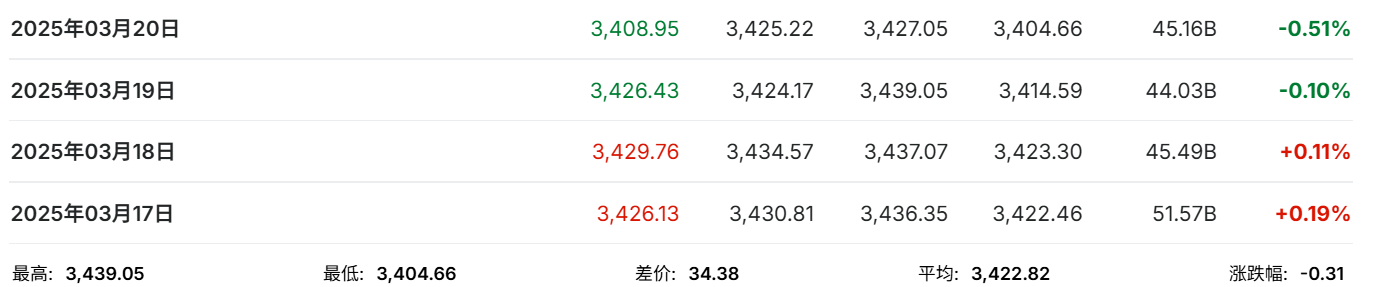
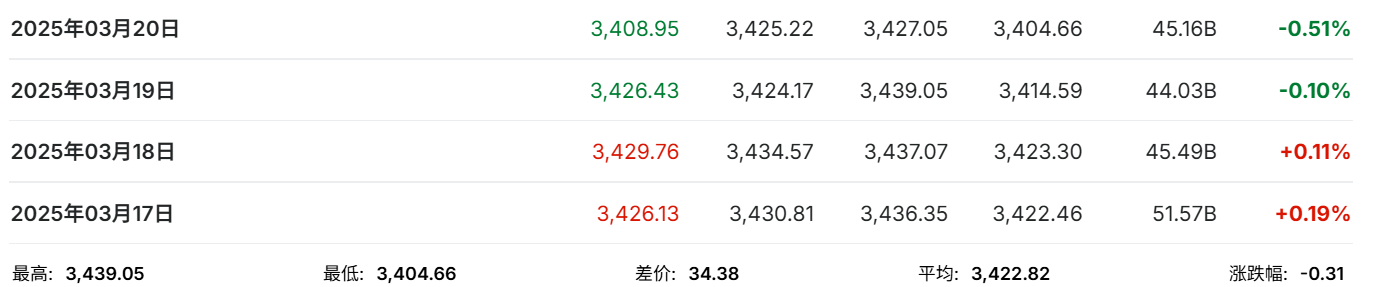

In [7]:
final = pd.read_csv('./data/final.csv')
final.insert_time = pd.to_datetime(final['insert_time'])
final['day'] = final.insert_time.dt.day
final.groupby('day').agg(emotion=('label','mean'))

,emotion
day,
15,0.171767
16,0.284494
17,0.351858
18,0.346933
19,0.352309


## 七、可以改进的方法

1.对于大语言模型的使用可以直接选取能绑定mcp工具的轻量级模型，或者github上存在专门针对金融新闻的语言训练模型如： https://github.com/guangxiangdebizi/FinanceMCP 使用大语言模型进行情感文本识别有些降维打击的同时，比较浪费，虽然通过多种手段将token消耗降低。可以将ollma模型作为语言识别模型，保存输出的数字为list，最后使用qwen操控mcp写入，这样最大程度上减少了token的消耗量。

2.在计算当日情绪的时候，可以通过降低反复出现的文章内容进行去重，但是此处比较困难。



## Optional_Task_0 同理，该步骤可以衔接所给出的行情数据进行额外探讨并完成任务二

共找到 3 个交易日：[datetime.date(2025, 3, 17), datetime.date(2025, 3, 18), datetime.date(2025, 3, 19)]


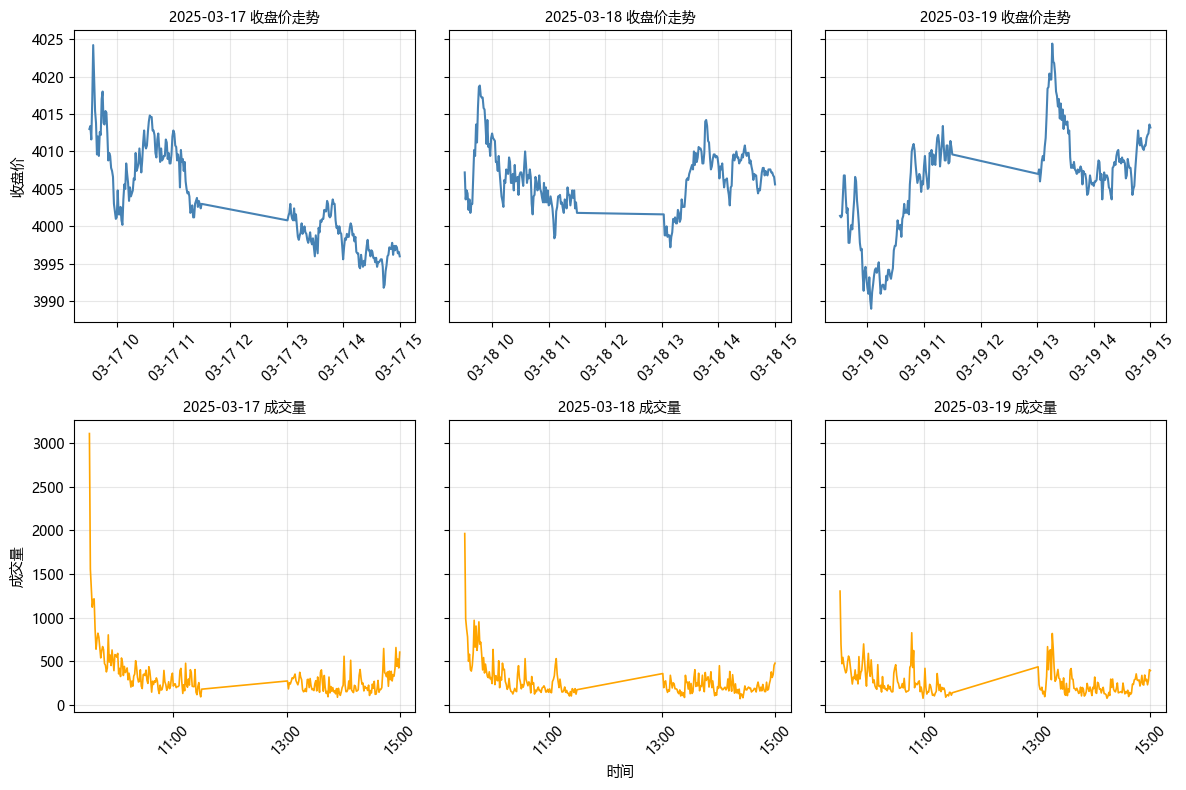

In [26]:
# template

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# === 中文显示 ===
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# === 数据加载 ===
trend = pd.read_csv(r'./笔试内容/行情.csv')
trend['datetime'] = pd.to_datetime(trend['datetime'])

# 筛选时间段
start_date = datetime(2025, 3, 15)
end_date = datetime(2025, 3, 20)
mask = (trend['datetime'] > start_date) & (trend['datetime'] < end_date)
trend_sel = trend.loc[mask].copy()

# === 自动获取日期列表 ===
days = sorted(trend_sel['datetime'].dt.date.unique())
n_days = len(days)

print(f"共找到 {n_days} 个交易日：{days}")

# === 创建 subplot ===
fig, axes = plt.subplots(2, n_days, figsize=(4*n_days, 8), sharey='row')

# 保证axes是二维数组（即使只有1天）
axes = axes.reshape(2, n_days)

for i, day in enumerate(days):
    day_data = trend_sel[trend_sel['datetime'].dt.date == day]

    # === 上方子图：收盘价 ===
    ax_price = axes[0, i]
    ax_price.plot(day_data['datetime'], day_data['close'], color='steelblue', linewidth=1.5)
    ax_price.set_title(f"{day} 收盘价走势", fontsize=10)
    ax_price.grid(True, alpha=0.3)

    # === 下方子图：成交量 ===
    ax_vol = axes[1, i]
    ax_vol.plot(day_data['datetime'], day_data['volume'], color='orange', linewidth=1.2)
    ax_vol.set_title(f"{day} 成交量", fontsize=10)
    ax_vol.grid(True, alpha=0.3)

    # 格式化时间轴
    ax_vol.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    ax_vol.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    for ax in [ax_price, ax_vol]:
        ax.tick_params(axis='x', rotation=45)

# 设置统一标签
axes[0,0].set_ylabel("收盘价")
axes[1,0].set_ylabel("成交量")
axes[1, n_days//2].set_xlabel("时间")

plt.tight_layout()
plt.show()


In [27]:
trend_sel['day'] = trend_sel.datetime.dt.day
result = (
    trend_sel.groupby('day').agg(
        p_withdrawal=('close',lambda x: x.max() - x.min()),
        p_rate= ('close',lambda x: x.iloc[-1] - x.iloc[0]))
    ).reset_index()
result

,day,p_withdrawal,p_rate,v_rate
0,17,32.4,-17.0,-2503.0
1,18,21.6,-1.6,-1484.0
2,19,35.4,11.8,-910.0


## Optional_Task_1 合成日频率数据
    基本定义字段：时间（日）、当日开仓价格、当日平仓价格、当日累计成交量、当日最高价格、当日最低价格
    但不存在volume，故而删除字段累计成交量；
    当日最高最低价同样可能存在偏差，由于只给出分钟数据的close价格
    合并结果保存至data文件夹中

In [39]:
date_trend = trend.copy()
date_trend['date'] = date_trend.datetime.dt.date
date_csv = date_trend.groupby('date').agg(
    open=('close',lambda x: x.iloc[0]),
    close=('close',lambda x: x.iloc[-1]),
    high=('close',lambda x: x.min()),
    low=('close',lambda x: x.max()),
    open_interest=('open_interest',lambda x: x.iloc[-1]),
)
date_csv.to_csv('./data/日行情.csv',index=True)


## Optional_Task_2 有效因子一
行情数据中给出了open_interest，表示此时该合约未平仓数量，虽然该合约从cell19图表中判断不存在夜盘，故而可能是A股股票（不存在空头），但在该假设里，将其当作多空都可的某期货合约行情数据。令OpenInterest= OI， Close = C
原理猜想
OI上升表示增仓的人，C上升表示多头增持，但增仓不一定增加close，可能有人在托住底盘，甚至有人在开空仓。当主力抱着拉升价格进场时，C上升是必然的，但OI却不应该会增大许多，因为此时主力会扫盘未成交合约，且以理性人的思考，主力不会高于最低市价进行扫盘，故而主力本身不会将OI变大。

故而定义以下逻辑

1.**多头主力进场信号：**

-当OI变小且C变大的时候，表示多头高处开仓(该逻辑不能用在空头侧）

2.**多空头主力减持信号（散户趋势追逐进场信号）：**

-当OI变大且C变小的时候表示多头减持平仓

基于上述逻辑可以构建因子：

OI_rate = 前一bar_OI - 前五bar_OI平均值

C_rate = 前一bar_C - 前五bar_C平均值

当bar delta = 1时，多头主力进场

当bar delta = 0时，无信号

当bar delta = -1时，多头主力退场


In [51]:
df_delta = pd.read_csv('./data/日行情.csv')
df_delta['OI_rate'] = df_delta.open_interest.shift(1) - df_delta['open_interest'].shift(2).rolling(window=5).apply(lambda x: x.mean())
df_delta['C_rate'] = df_delta.close.shift(1) - df_delta['close'].shift(2).rolling(window=5).apply(lambda x: x.mean())
df_delta.dropna(inplace=True)
df_delta['delta'] = df_delta.apply(lambda row: 1 if (row.OI_rate < 0 and  row.C_rate>0 ) else (-1 if row.OI_rate>0 and row.C_rate < 0 else 0), axis=1)
df_delta

,date,open,close,high,low,open_interest,OI_rate,C_rate,delta
6,2015-01-13,3531.2,3529.6,3503.4,3564.6,77162.0,-33345.0,-78.68,0
7,2015-01-14,3544.6,3504.2,3476.4,3555.0,63228.0,-26204.8,-59.92,0
8,2015-01-15,3505.8,3625.0,3485.2,3625.0,21979.0,-30123.8,-59.88,0
9,2015-01-16,3682.8,3667.2,3664.0,3710.4,114442.0,-61111.6,92.72,1
10,2015-01-19,3482.8,3316.2,3316.2,3511.8,117624.0,48004.0,122.32,0
...,...,...,...,...,...,...,...,...,...
2609,2025-09-24,4494.4,4556.2,4493.6,4556.6,58963.0,5570.2,0.08,0
2610,2025-09-25,4554.2,4585.0,4551.6,4610.4,59117.0,2857.4,47.40,0
2611,2025-09-26,4584.6,4543.2,4543.2,4591.0,56282.0,3529.4,75.60,0
2612,2025-09-29,4538.0,4623.6,4537.2,4649.6,61954.0,-3224.0,14.24,1


## Optional_Task_2 有效因子二：
新闻情绪因子，结合上述任务一中所完成的结果，识别该合约与新闻情绪的变化，因子构成逻辑比较简单。新闻情绪对市场大盘存在一定影响，而大盘表现对合约存在一定影响。在这种情况下，通过CAPM模型算出合约的beta因子，将其作为加权因子，把新闻情绪表现纳入到特征因子中
结构为：

**signal = beta*新闻情绪置信度**


此处需要大盘数据计算beta